<a href="https://colab.research.google.com/github/sanjananagendra16-cpu/Advanced-Machine-Learning/blob/main/AML_Individual_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

In [ ]:
df = pd.read_csv("BankNote_Authentication.csv")

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Shape: (1372, 5)

Columns: ['variance', 'skewness', 'curtosis', 'entropy', 'class']

Missing values:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


In [ ]:
# Rename columns if required
df.columns = ["variance", "skewness", "curtosis", "entropy", "class"]

print(df.head())
print("\nClass distribution:")
print(df["class"].value_counts())

   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Class distribution:
class
0    762
1    610
Name: count, dtype: int64


In [ ]:
# Features and target
X = df.drop("class", axis=1)
y = df["class"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1097
Testing samples: 275


In [ ]:
# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization completed.")

Standardization completed.


In [ ]:
nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)

print("Naive Bayes Predictions:")
print(y_pred_nb)

Naive Bayes Predictions:
[0 1 0 1 1 0 0 0 1 1 0 1 0 0 0 0 1 1 1 0 0 1 1 0 0 1 1 1 0 0 0 0 0 1 1 1 0
 1 0 0 1 0 1 0 1 1 0 0 0 1 0 1 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0
 0 1 1 0 0 1 1 0 1 1 0 1 1 1 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 1 1
 1 0 0 1 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 0 0 1 1 1 0 0 1 1 1 1 1 0 1 0 1 0 0
 0 0 0 0 1 1 0 0 1 0 1 0 1 0 1 0 0 0 0 1 0 0 1 1 1 0 1 0 1 0 0 1 0 0 1 0 0
 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 0 0 1 1 1 0 1 0 1 1 1 0 1 1 0 0 1 1 0 1 0 1
 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0
 0 1 0 1 1 0 0 1 0 0 1 0 0 0 0 0]


In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("Naive Bayes Confusion Matrix:")
print(cm_nb)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=["Forged", "Genuine"]
))

Naive Bayes Confusion Matrix:
[[135  18]
 [ 21 101]]

Classification Report:
              precision    recall  f1-score   support

      Forged       0.87      0.88      0.87       153
     Genuine       0.85      0.83      0.84       122

    accuracy                           0.86       275
   macro avg       0.86      0.86      0.86       275
weighted avg       0.86      0.86      0.86       275



In [ ]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average="weighted")
recall_nb = recall_score(y_test, y_pred_nb, average="weighted")
f1_nb = f1_score(y_test, y_pred_nb, average="weighted")

print("Naive Bayes Metrics")
print("-------------------")
print("Accuracy :", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Recall   :", round(recall_nb, 4))
print("F1 Score :", round(f1_nb, 4))

Naive Bayes Metrics
-------------------
Accuracy : 0.8582
Precision: 0.858
Recall   : 0.8582
F1 Score : 0.858


In [ ]:
# Find best K
k_values = range(1, 21)
k_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    prediction = model.predict(X_test_scaled)

    k_accuracies.append(
        accuracy_score(y_test, prediction)
    )

best_k = k_values[np.argmax(k_accuracies)]

print("Best K:", best_k)
print("Best Accuracy:", max(k_accuracies))

Best K: 1
Best Accuracy: 1.0


In [ ]:
knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Predictions:")
print(y_pred_knn)

KNN Predictions:
[0 1 0 1 1 1 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 1 1 1 0
 1 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0
 1 0 1 0 0 1 1 0 1 1 0 1 0 1 1 1 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1
 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 1 1 0 1 0 1 0 1 0 1
 0 0 1 0 1 1 0 0 1 0 1 0 1 0 0 1 0 0 1 1 0 0 1 1 0 0 1 1 1 0 0 1 0 0 0 0 0
 1 0 1 1 1 0 1 0 1 0 0 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 0 1 0 0
 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 1 0
 0 0 0 1 1 0 0 1 0 1 1 0 0 0 0 0]


In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("KNN Confusion Matrix:")
print(cm_knn)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=["Forged", "Genuine"]
))

KNN Confusion Matrix:
[[153   0]
 [  0 122]]

Classification Report:
              precision    recall  f1-score   support

      Forged       1.00      1.00      1.00       153
     Genuine       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



In [ ]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average="weighted")
recall_knn = recall_score(y_test, y_pred_knn, average="weighted")
f1_knn = f1_score(y_test, y_pred_knn, average="weighted")

print("KNN Metrics")
print("-----------")
print("Accuracy :", round(accuracy_knn, 4))
print("Precision:", round(precision_knn, 4))
print("Recall   :", round(recall_knn, 4))
print("F1 Score :", round(f1_knn, 4))

KNN Metrics
-----------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [ ]:
# Scale complete dataset
scaler_kmeans = StandardScaler()
X_scaled = scaler_kmeans.fit_transform(X)

# K-Means with 2 clusters
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print("K-Means Cluster Labels:")
print(clusters)

K-Means Cluster Labels:
[0 0 1 ... 1 1 1]


In [ ]:
print("Cluster Centers:")
print(pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
))

print("\nWCSS / Inertia:")
print(kmeans.inertia_)

silhouette = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score:")
print(silhouette)

Cluster Centers:
   variance  skewness  curtosis   entropy
0  0.046300  0.808792 -0.690054 -0.683669
1 -0.042919 -0.749723  0.639657  0.633738

WCSS / Inertia:
3453.291925672979

Silhouette Score:
0.32913879034236854


In [ ]:
# Automatically find the best cluster-label mapping
accuracy_1 = accuracy_score(y, clusters)
accuracy_2 = accuracy_score(y, 1 - clusters)

if accuracy_1 >= accuracy_2:
    kmeans_pred = clusters
else:
    kmeans_pred = 1 - clusters

cm_kmeans = confusion_matrix(y, kmeans_pred)

print("K-Means Confusion Matrix:")
print(cm_kmeans)

K-Means Confusion Matrix:
[[409 353]
 [252 358]]


In [ ]:
accuracy_kmeans = accuracy_score(y, kmeans_pred)
precision_kmeans = precision_score(y, kmeans_pred, average="weighted")
recall_kmeans = recall_score(y, kmeans_pred, average="weighted")
f1_kmeans = f1_score(y, kmeans_pred, average="weighted")

ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)

print("K-Means Metrics")
print("---------------")
print("Accuracy :", round(accuracy_kmeans, 4))
print("Precision:", round(precision_kmeans, 4))
print("Recall   :", round(recall_kmeans, 4))
print("F1 Score :", round(f1_kmeans, 4))
print("Silhouette Score:", round(silhouette, 4))
print("ARI:", round(ari, 4))
print("NMI:", round(nmi, 4))

K-Means Metrics
---------------
Accuracy : 0.559
Precision: 0.5675
Recall   : 0.559
F1 Score : 0.5602
Silhouette Score: 0.3291
ARI: 0.0132
NMI: 0.011


In [ ]:
results = pd.DataFrame({
    "Algorithm": [
        "Naive Bayes",
        "KNN",
        "K-Means"
    ],
    "Accuracy": [
        accuracy_nb,
        accuracy_knn,
        accuracy_kmeans
    ],
    "Precision": [
        precision_nb,
        precision_knn,
        precision_kmeans
    ],
    "Recall": [
        recall_nb,
        recall_knn,
        recall_kmeans
    ],
    "F1 Score": [
        f1_nb,
        f1_knn,
        f1_kmeans
    ]
})

print(results.round(4))

     Algorithm  Accuracy  Precision  Recall  F1 Score
0  Naive Bayes    0.8582     0.8580  0.8582    0.8580
1          KNN    1.0000     1.0000  1.0000    1.0000
2      K-Means    0.5590     0.5675  0.5590    0.5602


In [ ]:
# Convert to percentage
results_percentage = results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    results_percentage[column] = (
        results_percentage[column] * 100
    ).round(2).astype(str) + "%"

print(results_percentage)

     Algorithm Accuracy Precision  Recall F1 Score
0  Naive Bayes   85.82%     85.8%  85.82%    85.8%
1          KNN   100.0%    100.0%  100.0%   100.0%
2      K-Means    55.9%    56.75%   55.9%   56.02%


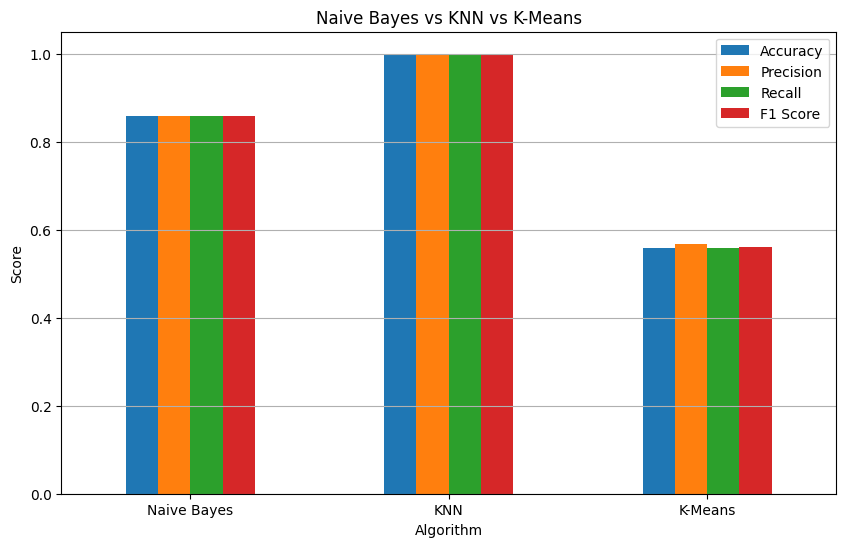

In [ ]:
results.set_index("Algorithm").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Naive Bayes vs KNN vs K-Means")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [ ]:
best_algorithm = results.loc[
    results["F1 Score"].idxmax(),
    "Algorithm"
]

best_accuracy = results.loc[
    results["F1 Score"].idxmax(),
    "Accuracy"
]

print("Best Algorithm:", best_algorithm)
print("Accuracy:", round(best_accuracy * 100, 2), "%")
print("Reason: Highest F1-score among the three algorithms.")

Best Algorithm: KNN
Accuracy: 100.0 %
Reason: Highest F1-score among the three algorithms.
